In [31]:
# Cell 1 — Imports and WRDS Connection

import wrds
import pandas as pd
import numpy as np
from pathlib import Path

# Connect to WRDS (will prompt for your username and password first time)
# After first login it saves credentials so you won't need to type them again
db = wrds.Connection()

# Always saves to notebooks/data/ regardless of where notebook is run from
data_path = Path('data')
data_path.mkdir(exist_ok=True)
print(f"Data will be saved to: {data_path.resolve()}")

print("Connected to WRDS successfully")

WRDS recommends setting up a .pgpass file.
pgpass file created at C:\Users\suus9\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Data will be saved to: C:\Users\suus9\OneDrive\Bureaublad\AI_Finance\Assignment\ai-finance-project\notebooks\data
Connected to WRDS successfully


In [ ]:
# ── Cell 2 — WRDS Pull ───────────────────────────────────────────────────────
# Set to True ONLY if you need fresh CRSP data from WRDS (~30 min)
PULL_FROM_WRDS = False

if not PULL_FROM_WRDS:
    print("Section 2 skipped — using existing raw files in data/ folder.")
    print("Set PULL_FROM_WRDS = True if you need fresh CRSP data.")
else:
    db = wrds.Connection()
    print("Connected to WRDS successfully")

    for year in range(1990, 2024):
        for month in range(1, 13):

            month_file = data_path / f"raw_{year}_{month:02d}.csv"
            if month_file.exists():
                print(f"{year}-{month:02d}: already saved, skipping...")
                continue

            last_day = calendar.monthrange(year, month)[1]
            print(f"Pulling {year}-{month:02d}...")

            query = f"""
                SELECT
                    a.permno,
                    a.date,
                    a.ret,
                    ABS(a.prc)                          AS prc,
                    a.shrout,
                    ABS(a.prc) * a.shrout               AS mktcap,
                    a.vol,
                    CASE
                        WHEN ABS(a.prc) * a.vol > 0
                        THEN ABS(a.ret) / (ABS(a.prc) * a.vol)
                        ELSE NULL
                    END                                 AS amihud_illiquidity,
                    b.shrcd,
                    b.exchcd
                FROM crsp.dsf AS a
                LEFT JOIN crsp.msenames AS b
                    ON a.permno = b.permno
                    AND a.date BETWEEN b.namedt AND b.nameendt
                WHERE a.date BETWEEN '{year}-{month:02d}-01'
                    AND '{year}-{month:02d}-{last_day}'
                    AND a.ret     IS NOT NULL
                    AND a.prc     IS NOT NULL
                    AND a.shrout  IS NOT NULL
                    AND a.vol     IS NOT NULL
                    AND b.shrcd   IN (10, 11)
                    AND b.exchcd  IN (1, 2, 3)
            """

            df_month = db.raw_sql(query, date_cols=['date'])
            df_month.to_csv(month_file, index=False)
            del df_month
            print(f"  Saved {year}-{month:02d}")

    print("\nAll months pulled and saved!")

1990-01: already saved, skipping...
1990-02: already saved, skipping...
1990-03: already saved, skipping...
1990-04: already saved, skipping...
1990-05: already saved, skipping...
1990-06: already saved, skipping...
1990-07: already saved, skipping...
1990-08: already saved, skipping...
1990-09: already saved, skipping...
1990-10: already saved, skipping...
1990-11: already saved, skipping...
1990-12: already saved, skipping...
1991-01: already saved, skipping...
1991-02: already saved, skipping...
1991-03: already saved, skipping...
1991-04: already saved, skipping...
1991-05: already saved, skipping...
1991-06: already saved, skipping...
1991-07: already saved, skipping...
1991-08: already saved, skipping...
1991-09: already saved, skipping...
1991-10: already saved, skipping...
1991-11: already saved, skipping...
1991-12: already saved, skipping...
1992-01: already saved, skipping...
1992-02: already saved, skipping...
1992-03: already saved, skipping...
1992-04: already saved, skip

In [41]:
import calendar
import gc

all_files = sorted(data_path.glob("raw_*.csv"))
print(f"Found {len(all_files)} monthly files")

monthly_dfs = []

for i, f in enumerate(all_files):
    if i % 12 == 0:
        print(f"Processing {f.name}...")
    
    # Load one month at a time
    df = pd.read_csv(f, parse_dates=['date'])
    
    # Add year_month column
    df['year_month'] = df['date'].dt.to_period('M')
    
    # Apply price filter
    df = df[df['prc'] >= 1]
    
    # Aggregate to monthly immediately
    monthly = df.groupby(['permno', 'year_month']).agg(
        ret           = ('ret', lambda x: (1 + x).prod() - 1),
        real_vol_monthly = ('ret', 'std'),
        mktcap        = ('mktcap', 'last'),
        liquidity     = ('amihud_illiquidity', 'mean'),
        prc           = ('prc', 'last'),
        n_days        = ('ret', 'count')
    ).reset_index()
    
    monthly_dfs.append(monthly)
    
    # Free memory immediately
    del df
    gc.collect()

# Combine aggregated monthly data — much smaller than raw
print("\nCombining aggregated monthly data...")
df_monthly = pd.concat(monthly_dfs, ignore_index=True)
print(f"Monthly panel shape: {df_monthly.shape}")
print(df_monthly.head())

Found 408 monthly files
Processing raw_1990_01.csv...
Processing raw_1991_01.csv...
Processing raw_1992_01.csv...
Processing raw_1993_01.csv...
Processing raw_1994_01.csv...
Processing raw_1995_01.csv...
Processing raw_1996_01.csv...
Processing raw_1997_01.csv...
Processing raw_1998_01.csv...
Processing raw_1999_01.csv...
Processing raw_2000_01.csv...
Processing raw_2001_01.csv...
Processing raw_2002_01.csv...
Processing raw_2003_01.csv...
Processing raw_2004_01.csv...
Processing raw_2005_01.csv...
Processing raw_2006_01.csv...
Processing raw_2007_01.csv...
Processing raw_2008_01.csv...
Processing raw_2009_01.csv...
Processing raw_2010_01.csv...
Processing raw_2011_01.csv...
Processing raw_2012_01.csv...
Processing raw_2013_01.csv...
Processing raw_2014_01.csv...
Processing raw_2015_01.csv...
Processing raw_2016_01.csv...
Processing raw_2017_01.csv...
Processing raw_2018_01.csv...
Processing raw_2019_01.csv...
Processing raw_2020_01.csv...
Processing raw_2021_01.csv...
Processing raw_2

In [42]:
# Cell 4 — Add market-level features and lagged volatility

# Annualize volatility
df_monthly['real_vol_ann'] = df_monthly['real_vol_monthly'] * np.sqrt(12)

# Apply minimum 15 trading days filter
df_monthly = df_monthly[df_monthly['n_days'] >= 15]

# Drop duplicates first
df_monthly = df_monthly.drop_duplicates(subset=['permno', 'year_month'])
print(f"Shape after dropping duplicates: {df_monthly.shape}")

# Market vol — std of equal weighted market return per month
# Load raw files again to compute proper market return
all_files = sorted(data_path.glob("raw_*_*.csv"))  # only monthly files

mkt_rows = []
for f in all_files:
    df = pd.read_csv(f, parse_dates=['date'])
    df['year_month'] = df['date'].dt.to_period('M')
    # Equal weighted market return per day
    mkt_daily = df.groupby('date')['ret'].mean().reset_index()
    mkt_daily['year_month'] = mkt_daily['date'].dt.to_period('M')
    # Std of daily market returns within month, then annualize
    mkt_month = mkt_daily.groupby('year_month')['ret'].std().reset_index()
    mkt_month.columns = ['year_month', 'mkt_vol_monthly']
    mkt_rows.append(mkt_month)
    del df
    
mkt_vol = pd.concat(mkt_rows).groupby('year_month')['mkt_vol_monthly'].mean().reset_index()
mkt_vol['mkt_vol_ann'] = mkt_vol['mkt_vol_monthly'] * np.sqrt(252)  # daily vol annualized

# Merge market vol back
df_monthly = df_monthly.merge(mkt_vol, on='year_month', how='left')

# High vol regime flag
df_monthly['high_vol_regime'] = df_monthly['mkt_vol_ann'] > 0.30

# Lagged market vol — used as exit signal in Topic 3
# Computed at market level since mkt_vol_ann is identical for all stocks in a month
mkt_vol_lag = df_monthly.drop_duplicates('year_month')[['year_month', 'mkt_vol_ann']].sort_values('year_month')
mkt_vol_lag['mkt_vol_ann_lag1'] = mkt_vol_lag['mkt_vol_ann'].shift(1)
df_monthly = df_monthly.merge(mkt_vol_lag[['year_month', 'mkt_vol_ann_lag1']], on='year_month', how='left')

# Sort before computing lags
df_monthly = df_monthly.sort_values(['permno', 'year_month']).reset_index(drop=True)

# Lagged volatility
df_monthly['real_vol_ann_lag1'] = df_monthly.groupby('permno')['real_vol_ann'].shift(1)
df_monthly['real_vol_ann_lag2'] = df_monthly.groupby('permno')['real_vol_ann'].shift(2)
df_monthly['real_vol_ann_lag3'] = df_monthly.groupby('permno')['real_vol_ann'].shift(3)

print(f"Shape after adding features: {df_monthly.shape}")
print(f"High vol regime months: {df_monthly[df_monthly['high_vol_regime']]['year_month'].nunique()}")
print(f"Sample high vol months: {sorted(df_monthly[df_monthly['high_vol_regime']]['year_month'].unique())[:10]}")
print(df_monthly[['permno', 'year_month', 'real_vol_ann', 'mkt_vol_ann', 'high_vol_regime', 'real_vol_ann_lag1']].head(5))

Shape after dropping duplicates: (1915282, 9)
Shape after adding features: (1915282, 16)
High vol regime months: 24
Sample high vol months: [Period('1998-10', 'M'), Period('2000-04', 'M'), Period('2000-12', 'M'), Period('2001-09', 'M'), Period('2008-09', 'M'), Period('2008-10', 'M'), Period('2008-11', 'M'), Period('2008-12', 'M'), Period('2009-01', 'M'), Period('2009-02', 'M')]
   permno year_month  real_vol_ann  mkt_vol_ann  high_vol_regime  \
0   10001    1990-01      0.037405     0.108909            False   
1   10001    1990-02      0.050277     0.062140            False   
2   10001    1990-03      0.084487     0.050181            False   
3   10001    1990-04      0.049395     0.050042            False   
4   10001    1990-05      0.061150     0.032352            False   

   real_vol_ann_lag1  
0                NaN  
1           0.037405  
2           0.050277  
3           0.084487  
4           0.049395  


In [43]:
# Cell 5 — Final column selection and save

clean = df_monthly[[
    'permno',
    'year_month',
    'ret',
    'real_vol_monthly',
    'real_vol_ann',
    'real_vol_ann_lag1',
    'real_vol_ann_lag2',
    'real_vol_ann_lag3',
    'mktcap',
    'liquidity',
    'mkt_vol_ann',
    'mkt_vol_ann_lag1',
    'high_vol_regime',
    'n_days'
]].copy()

# Convert year_month to timestamp
clean['date'] = clean['year_month'].dt.to_timestamp('M')
clean = clean.drop(columns=['year_month'])

# Sort
clean = clean.sort_values(['date', 'permno']).reset_index(drop=True)

print(f"Final panel shape: {clean.shape}")
print(f"Columns: {clean.columns.tolist()}")
print(f"Date range: {clean['date'].min()} to {clean['date'].max()}")
print(clean.head())

# Save
clean.to_csv(data_path / 'clean_monthly_panel.csv', index=False)
print("\nSaved to data/clean_monthly_panel.csv")

Final panel shape: (1915282, 14)
Columns: ['permno', 'ret', 'real_vol_monthly', 'real_vol_ann', 'real_vol_ann_lag1', 'real_vol_ann_lag2', 'real_vol_ann_lag3', 'mktcap', 'liquidity', 'mkt_vol_ann', 'mkt_vol_ann_lag1', 'high_vol_regime', 'n_days', 'date']
Date range: 1990-01-31 00:00:00 to 2023-12-31 00:00:00
   permno       ret  real_vol_monthly  real_vol_ann  real_vol_ann_lag1  \
0   10001 -0.018519          0.010798      0.037405                NaN   
1   10002  0.020408          0.004351      0.015072                NaN   
2   10003 -0.088235          0.049991      0.173174                NaN   
3   10007 -0.474885          0.077862      0.269721                NaN   
4   10009 -0.103449          0.036663      0.127005                NaN   

   real_vol_ann_lag2  real_vol_ann_lag3     mktcap     liquidity  mkt_vol_ann  \
0                NaN                NaN  10156.125  4.070197e-07     0.108909   
1                NaN                NaN   7343.750  0.000000e+00     0.108909   
2  

In [44]:
print(f"Total stocks: {clean['permno'].nunique()}")
print(f"Total months: {clean['date'].nunique()}")
print(f"Avg stocks per month: {clean.groupby('date')['permno'].count().mean():.0f}")
print(f"Min price: {clean['ret'].min():.4f}")
print(f"Min n_days: {clean['n_days'].min()}")
print(f"Any n_days < 15: {(clean['n_days'] < 15).sum()}")

Total stocks: 18083
Total months: 408
Avg stocks per month: 4694
Min price: -0.9957
Min n_days: 15
Any n_days < 15: 0


In [46]:
# Cell 5 — Additional filters + lagged features

# Sort first
clean = clean.sort_values(['permno', 'date']).reset_index(drop=True)

# Lagged return features (shift first to avoid lookahead bias)
clean['ret_lag1'] = clean.groupby('permno')['ret'].shift(1)
clean['ret_lag3'] = clean.groupby('permno')['ret'].shift(1).rolling(3).mean()
clean['ret_lag6'] = clean.groupby('permno')['ret'].shift(1).rolling(6).mean()
clean['abs_ret_lag1'] = clean.groupby('permno')['ret'].shift(1).abs()
clean['mktcap_lag1'] = clean.groupby('permno')['mktcap'].shift(1)
clean['momentum_12m'] = (
    clean.groupby('permno')['ret']
    .shift(1)
    .rolling(12)
    .sum()
)
print("Lagged features added ✅")

# Return filter
print(f"Before return filter: {clean.shape}")
clean = clean[(clean['ret'] > -1) & (clean['ret'] < 10)]
print(f"After return filter: {clean.shape}")

# Microcap filter
print(f"Before microcap filter: {clean.shape}")
clean = clean[clean['mktcap'] > 1000]
print(f"After microcap filter: {clean.shape}")

Lagged features added ✅
Before return filter: (1914831, 20)
After return filter: (1914831, 20)
Before microcap filter: (1914831, 20)
After microcap filter: (1914831, 20)


In [47]:
from scipy.stats import mstats

# Winsorize at 1st and 99th percentile for key variables
for col in ['real_vol_ann', 'mktcap', 'liquidity']:
    clean[col] = clean.groupby('date')[col].transform(
        lambda x: mstats.winsorize(x, limits=[0.01, 0.01])
    )
    print(f"{col} winsorized ✅")

# Also update lagged vol columns
for col in ['real_vol_ann_lag1', 'real_vol_ann_lag2', 'real_vol_ann_lag3']:
    clean[col] = clean.groupby('date')[col].transform(
        lambda x: mstats.winsorize(x, limits=[0.01, 0.01])
    )
    print(f"{col} winsorized ✅")

print(f"\nFinal shape: {clean.shape}")
print(f"\nVol distribution after winsorization:")
print(clean['real_vol_ann'].describe())

# Remove remaining zero vol rows
print(f"Zero vol rows remaining: {(clean['real_vol_ann'] == 0).sum()}")
clean = clean[clean['real_vol_ann'] > 0]
print(f"Final shape: {clean.shape}")

# Resave
clean.to_csv(data_path / 'clean_monthly_panel.csv', index=False)
print("Saved to data/clean_monthly_panel.csv ✅")

real_vol_ann winsorized ✅
mktcap winsorized ✅
liquidity winsorized ✅
real_vol_ann_lag1 winsorized ✅
real_vol_ann_lag2 winsorized ✅
real_vol_ann_lag3 winsorized ✅

Final shape: (1914831, 20)

Vol distribution after winsorization:
count    1.914831e+06
mean     1.143234e-01
std      8.063285e-02
min      0.000000e+00
25%      5.895683e-02
50%      9.207958e-02
75%      1.451607e-01
max      7.710562e-01
Name: real_vol_ann, dtype: float64
Zero vol rows remaining: 2104
Final shape: (1912727, 20)
Saved to data/clean_monthly_panel.csv ✅


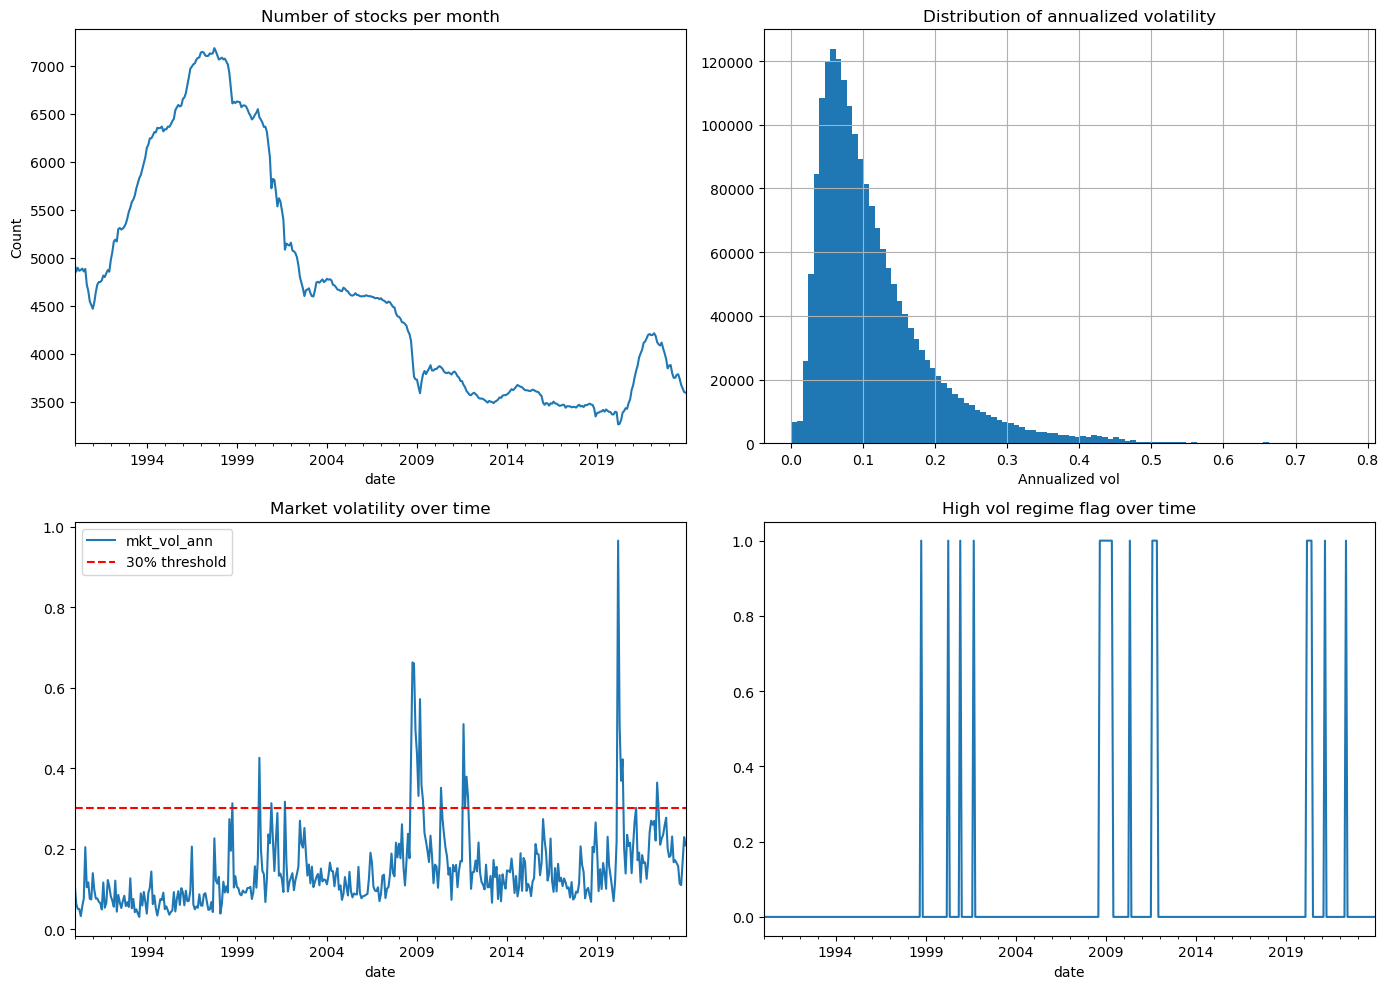

Plots saved!


In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — Stocks per month
clean.groupby('date')['permno'].count().plot(
    ax=axes[0,0], title='Number of stocks per month')
axes[0,0].set_ylabel('Count')

# Plot 2 — Vol distribution
clean['real_vol_ann'].hist(bins=100, ax=axes[0,1])
axes[0,1].set_title('Distribution of annualized volatility')
axes[0,1].set_xlabel('Annualized vol')

# Plot 3 — Market vol over time
clean.groupby('date')['mkt_vol_ann'].first().plot(
    ax=axes[1,0], title='Market volatility over time')
axes[1,0].axhline(0.30, color='red', linestyle='--', label='30% threshold')
axes[1,0].legend()

# Plot 4 — High vol regime
clean.groupby('date')['high_vol_regime'].first().astype(int).plot(
    ax=axes[1,1], title='High vol regime flag over time')

plt.tight_layout()
plt.savefig('data/sanity_check_plots.png')
plt.show()
print("Plots saved!")